In [65]:
from glob import glob
import librosa    
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sounds = glob("./data/sounds/*/*.wav")

In [66]:
def extract_features(y, sr):
    features = []  

    y_trimmed, _ = librosa.effects.trim(y=y, top_db=30)

    # RMS - root mean squared : energy / loudness over time
    rms = librosa.feature.rms(y=y)
    rms_mean = rms.mean()
    features.append(rms_mean)

    # ZCR - zero crossing rate : noise / frequency 
    zcr = librosa.feature.zero_crossing_rate(y)
    zcr_mean = zcr.mean()
    features.append(zcr_mean)

    # Spectral Centroid - "center of mass" : energy location on frequency spectrum : where is the noise coming from? 
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    centroid_mean = centroid.mean()
    features.append(centroid_mean)

    # Spectral Rolloff - "Below what frequency does most (default: 85%) of the energy lie?”
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = rolloff.mean()
    features.append(rolloff_mean)

    # bandwidth - "How spread out are the frequencies?"
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    bandwidth_mean = bandwidth.mean()
    features.append(bandwidth_mean)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=10)
    mfcc_means = mfcc.mean(axis=1)
    features.extend(mfcc_means)
    return features

X = []
y = []
for sound in sounds:
    waveform, sr = librosa.load(sound)
    features = extract_features(waveform, sr)
    label = Path(sound).parent.name
    # print(label)
    X.append(features)
    y.append(label)
print('done')

done


In [67]:
labels = sorted(set(y))
# X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, train_size=.8, stratify=y)
X_train = X
y_train = y

# scale
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
# X_test = ss.transform(X_test)

# model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
# pred = model.predict(X_test)
print('done')

done


In [63]:
# ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=labels)

# cr = classification_report(y_test, pred)
# print("Classification Report\n", cr)

# # make plots
# feature_names = [
#     "rms",
#     "zcr",
#     "centroid",
#     "rolloff",
#     "bandwidth",
# ] + [f"mfcc_{i}" for i in range(10)]

# df = pd.DataFrame(X, columns=feature_names)
# df["label"] = y

# fig, axes = plt.subplots(5, 3, figsize=(15, 15))

# for i, feature in enumerate(feature_names):
#     row = i // 3
#     col = i % 3
#     sns.boxplot(x="label", y=feature, data=df, ax=axes[row][col])
#     axes[row][col].set_title(feature)

# plt.tight_layout()

# plt.show()

In [69]:
# visualize new data
import IPython.display as ipd
beats = glob("./data/beats/*")
# beat = beats[1]

# wave_form, sample_rate = librosa.load(beat)
# pd.Series(wave_form).plot(figsize=(10,5), lw=1, title="Beat Visual", color="red")

# plt.show()

In [70]:
# ipd.Audio(beat)

In [81]:
def detect_onsets(y, sr):
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    onset_times = librosa.onset.onset_detect(
        onset_envelope=onset_env,
        sr=sr,
        units="time"
    )
    return onset_env, onset_times

def slice_hits(y, sr, onset_times, pre_time=0.03, post_time=0.1):
    hit_slices = []

    pre_samples = int(pre_time * sr)
    post_samples = int(post_time * sr)

    onset_samples = librosa.time_to_samples(onset_times, sr=sr)

    for onset in onset_samples:
        start = max(0, onset - pre_samples)
        end = min(len(y), onset + post_samples)

        hit = y[start:end]
        hit_slices.append(hit)

    return hit_slices

In [82]:
import librosa
from collections import defaultdict

X_hits = []
hit_times = []
hit_sources = []

for beat in beats:
    y, sr = librosa.load(beat)

    onset_env, onset_times = detect_onsets(y, sr)
    hit_slices = slice_hits(y, sr, onset_times)

    for onset_time, hit in zip(onset_times, hit_slices):
        features = extract_features(hit, sr)
        X_hits.append(features)
        hit_times.append(onset_time)
        hit_sources.append(beat)

X_hits = ss.transform(X_hits)
pred = model.predict(X_hits)

results = defaultdict(list)
for source, t, label in zip(hit_sources, hit_times, pred):
    results[source].append((t, label))

for source, events in results.items():
    print(f"\n{source}")
    for t, label in events:
        print(f"  {t:.3f}s -> {label}")


./data/beats\1_n_a.wav
  0.116s -> overheads
  0.372s -> toms
  0.627s -> toms
  0.882s -> overheads
  1.138s -> toms
  1.370s -> toms
  1.625s -> overheads
  1.881s -> toms
  1.997s -> toms
  2.136s -> overheads
  2.368s -> toms
  2.624s -> toms
  2.879s -> overheads
  3.135s -> toms
  3.367s -> toms
  3.622s -> overheads
  3.878s -> toms
  4.017s -> toms
  4.133s -> overheads
  4.389s -> toms
  4.621s -> toms
  4.876s -> overheads
  5.132s -> toms
  5.387s -> toms
  5.619s -> overheads
  5.875s -> toms
  6.014s -> toms
  6.130s -> overheads
  6.385s -> toms
  6.618s -> toms

./data/beats\4_on_floor.wav
  0.116s -> toms
  0.372s -> kick
  0.604s -> toms
  0.836s -> kick
  1.068s -> toms
  1.300s -> kick
  1.533s -> toms
  1.765s -> overheads

./data/beats\quick_beat.wav
  0.116s -> toms
  0.302s -> toms
  0.464s -> toms
  0.627s -> toms
  0.720s -> toms
  0.882s -> toms
  0.975s -> toms
  1.115s -> toms
  1.277s -> toms


C:\Users\lickw\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1739
  warnings.warn(


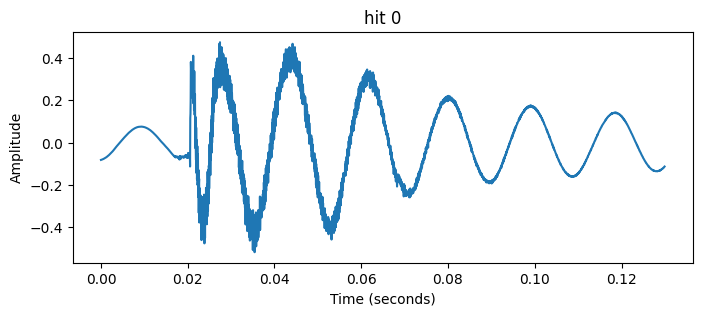

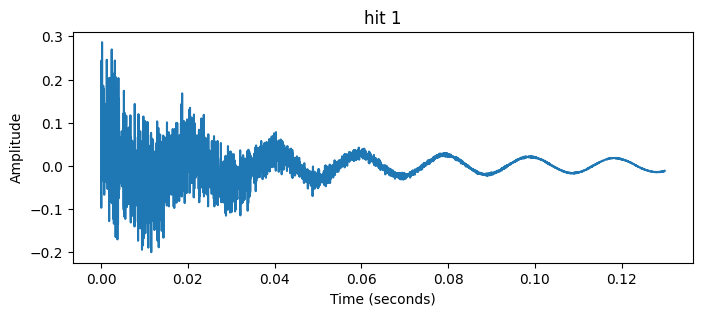

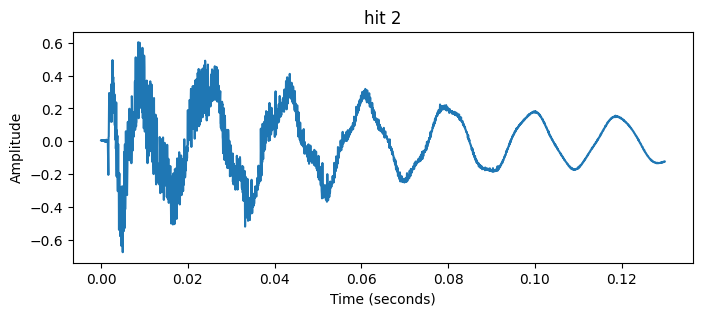

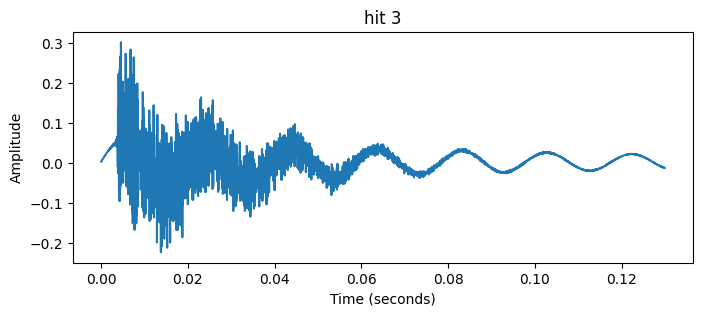

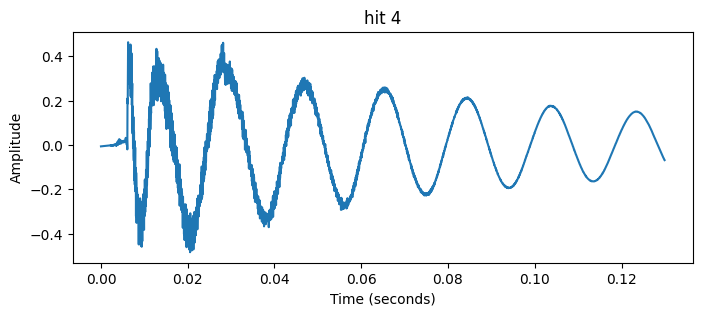

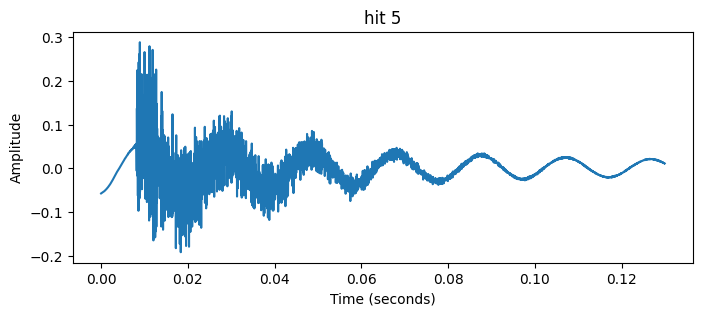

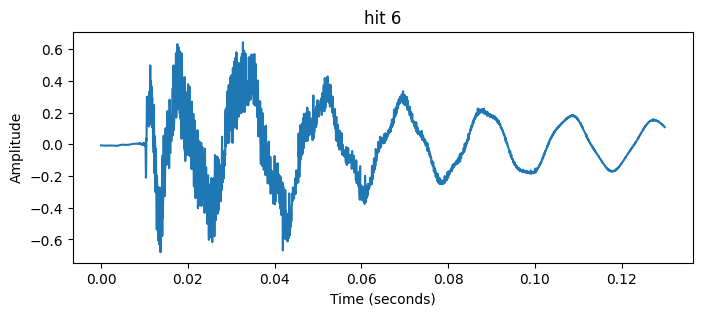

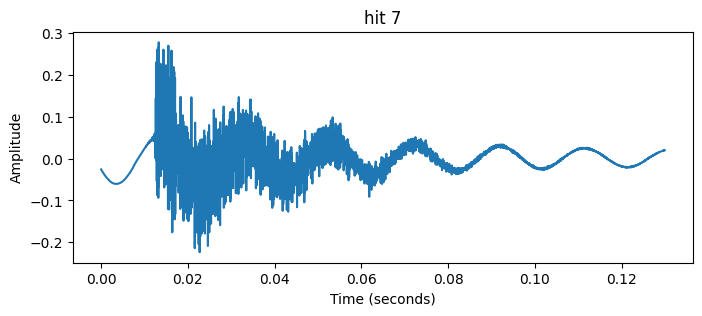

In [83]:
# times = np.arange(len(y)) / sr

# plt.figure(figsize=(12, 4))
# plt.plot(times, y)

# for t in onset_times:
#     plt.axvline(x=t)

# plt.xlabel("Time (s)")
# plt.ylabel("Amplitude")
# plt.title("Waveform with detected onsets")
# plt.show()

source = beats[1]  # third source (0-indexed)

y, sr = librosa.load(source)

# if you already have slicing:
onset_env, onset_times = detect_onsets(y, sr)
hit_slices = slice_hits(y, sr, onset_times)

for i, hit in enumerate(hit_slices):
    times = np.arange(len(hit)) / sr

    plt.figure(figsize=(8, 3))
    plt.plot(times, hit)
    plt.title(f"hit {i}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.show()